1. Syarif Sanad - 5025221257
2. Mirza Syahrizal Fathir - 5025231151
3. Aditya Fieansyah Putra Pratama - 5025231309
4. Felda Ega Fadhila - 5025231199

# Import Library

In [17]:
!pip install networkx python-louvain leidenalg igraph vaderSentiment pyvis pandas matplotlib seaborn tqdm

In [18]:
!pip install -q python-louvain
from community import community_louvain

In [19]:
import re
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
import community as community_louvain
from collections import defaultdict, Counter
from itertools import combinations
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from pyvis.network import Network
from tqdm import tqdm

warnings.filterwarnings("ignore")
tqdm.pandas()

DATASET_PATH = "/content/covid19_tweets.csv"
OUTPUT_DIR   = "/content/sna_outputs/"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Sampun")

Sampun


# Load and Inspect Data

In [20]:
df = pd.read_csv(DATASET_PATH, parse_dates=["date"])

print(f"Shape          : {df.shape}")
print(f"Date range     : {df['date'].min()} → {df['date'].max()}")
print(f"Unique users   : {df['user_name'].nunique():,}")
print(f"Missing text   : {df['text'].isna().sum()}")
print("\nColumn types:")
print(df.dtypes)
print("\nSample row:")
print(df.iloc[0])

Shape          : (179108, 13)
Date range     : 2020-07-24 23:47:08 → 2020-08-30 09:07:39
Unique users   : 92,276
Missing text   : 0

Column types:
user_name                   object
user_location               object
user_description            object
user_created                object
user_followers               int64
user_friends                 int64
user_favourites              int64
user_verified                 bool
date                datetime64[ns]
text                        object
hashtags                    object
source                      object
is_retweet                    bool
dtype: object

Sample row:
user_name                                                      ᏉᎥ☻լꂅϮ
user_location                                              astroworld
user_description    wednesday addams as a disney princess keepin i...
user_created                                      2017-05-26 05:46:42
user_followers                                                    624
user_friends         

# Text Cleaning Helpers

In [21]:
RT_PATTERN      = re.compile(r"RT @(\w+)", re.IGNORECASE)
MENTION_PATTERN = re.compile(r"(?<!RT )@(\w+)", re.IGNORECASE)
HASHTAG_PATTERN = re.compile(r"#(\w+)", re.IGNORECASE)

def extract_retweet_target(text):
    """Return the username being retweeted, or None."""
    m = RT_PATTERN.search(str(text))
    return m.group(1).lower() if m else None

def extract_mentions(text):
    """Return list of mentioned usernames (excluding RT target)."""
    return [m.lower() for m in MENTION_PATTERN.findall(str(text))]

def extract_hashtags(text):
    """Return list of hashtags (lower-cased, excluding covid19 itself)."""
    tags = HASHTAG_PATTERN.findall(str(text))
    return [t.lower() for t in tags if t.lower() not in ("covid19", "covid")]

print("Sampun.")

Sampun.


# Build Edge Lists

In [22]:
retweet_edges   = []   # (source, target, date)
mention_edges   = []   # (source, target, date)
hashtag_pairs   = []   # (tag1, tag2, date)

for _, row in tqdm(df.iterrows(), total=len(df)):
    src  = str(row["user_name"]).lower().strip()
    text = str(row["text"])
    date = row["date"]

    # Retweet edges
    rt_target = extract_retweet_target(text)
    if rt_target and rt_target != src:
        retweet_edges.append((src, rt_target, date))

    # Mention edges
    for mentioned in extract_mentions(text):
        if mentioned != src:
            mention_edges.append((src, mentioned, date))

    # Hashtag co-occurrence pairs
    tags = extract_hashtags(text)
    for pair in combinations(set(tags), 2):
        hashtag_pairs.append((min(pair), max(pair), date))

print(f"  Retweet edges  : {len(retweet_edges):,}")
print(f"  Mention edges  : {len(mention_edges):,}")
print(f"  Hashtag pairs  : {len(hashtag_pairs):,}")

# Save edge lists
rt_df   = pd.DataFrame(retweet_edges,  columns=["source", "target", "date"])
men_df  = pd.DataFrame(mention_edges,  columns=["source", "target", "date"])
hash_df = pd.DataFrame(hashtag_pairs,  columns=["tag1",   "tag2",   "date"])

rt_df.to_csv(OUTPUT_DIR + "retweet_edges.csv",  index=False)
men_df.to_csv(OUTPUT_DIR + "mention_edges.csv", index=False)
hash_df.to_csv(OUTPUT_DIR + "hashtag_pairs.csv",index=False)
print("Sampun.")

100%|██████████| 179108/179108 [00:17<00:00, 10436.08it/s]


  Retweet edges  : 231
  Mention edges  : 85,074
  Hashtag pairs  : 169,415
Sampun.


# Build User–User Graph

In [23]:
G = nx.DiGraph()

# Add retweet edges (weight = 2, stronger signal)
rt_agg = rt_df.groupby(["source", "target"]).size().reset_index(name="weight")
for _, row in rt_agg.iterrows():
    if G.has_edge(row.source, row.target):
        G[row.source][row.target]["weight"] += row.weight * 2
    else:
        G.add_edge(row.source, row.target, weight=row.weight * 2, edge_type="retweet")

# Add mention edges (weight = 1)
men_agg = men_df.groupby(["source", "target"]).size().reset_index(name="weight")
for _, row in men_agg.iterrows():
    if G.has_edge(row.source, row.target):
        G[row.source][row.target]["weight"] += row.weight
    else:
        G.add_edge(row.source, row.target, weight=row.weight, edge_type="mention")

print(f"  Nodes : {G.number_of_nodes():,}")
print(f"  Edges : {G.number_of_edges():,}")

  Nodes : 69,069
  Edges : 73,791


# Attach Node Attributes

In [24]:
user_meta = (
    df.sort_values("date")
      .drop_duplicates(subset="user_name", keep="last")
      [["user_name", "user_followers", "user_friends",
        "user_favourites", "user_verified", "user_location"]]
      .copy()
)
user_meta["user_name"] = user_meta["user_name"].str.lower().str.strip()

# Convert to dict of dicts — guarantees O(1) lookup, no Series ambiguity
meta_dict = {}
for _, row in user_meta.iterrows():
    uname = row["user_name"]
    if uname not in meta_dict:
        meta_dict[uname] = {
            "followers" : int(row["user_followers"])  if pd.notna(row["user_followers"])  else 0,
            "friends"   : int(row["user_friends"])    if pd.notna(row["user_friends"])    else 0,
            "verified"  : bool(row["user_verified"])  if pd.notna(row["user_verified"])   else False,
            "location"  : str(row["user_location"])   if pd.notna(row["user_location"])   else "",
        }

# Attach to graph nodes
default = {"followers": 0, "friends": 0, "verified": False, "location": ""}
for node in G.nodes():
    attrs = meta_dict.get(node, default)
    G.nodes[node]["followers"] = attrs["followers"]
    G.nodes[node]["friends"]   = attrs["friends"]
    G.nodes[node]["verified"]  = attrs["verified"]
    G.nodes[node]["location"]  = attrs["location"]


# Compute Centrality Metrics

In [25]:
# ── STEP 7: Compute centrality metrics ──────────────────────
print("\n⏳ Computing centrality metrics (this may take a few minutes) …")

in_deg   = dict(G.in_degree(weight="weight"))
out_deg  = dict(G.out_degree(weight="weight"))
pagerank = nx.pagerank(G, weight="weight", alpha=0.85, max_iter=200)

# Betweenness on largest weakly connected component (faster)
largest_wcc = max(nx.weakly_connected_components(G), key=len)
G_wcc       = G.subgraph(largest_wcc).copy()
print(f"  Largest WCC: {G_wcc.number_of_nodes():,} nodes")
betweenness = nx.betweenness_centrality(G_wcc, weight="weight", normalized=True, k=500)

# Assign back to full graph
nx.set_node_attributes(G, in_deg,    "in_degree")
nx.set_node_attributes(G, out_deg,   "out_degree")
nx.set_node_attributes(G, pagerank,  "pagerank")
nx.set_node_attributes(G, betweenness, "betweenness")

print("Sampun.")


⏳ Computing centrality metrics (this may take a few minutes) …
  Largest WCC: 41,270 nodes
Sampun.


# Node Table Export

In [26]:
node_records = []
for node, data in G.nodes(data=True):
    node_records.append({
        "user":         node,
        "in_degree":    data.get("in_degree",   0),
        "out_degree":   data.get("out_degree",  0),
        "pagerank":     data.get("pagerank",    0),
        "betweenness":  data.get("betweenness", 0),
        "followers":    data.get("followers",   0),
        "friends":      data.get("friends",     0),
        "verified":     data.get("verified",    False),
        "location":     data.get("location",    ""),
    })

node_df = pd.DataFrame(node_records).sort_values("pagerank", ascending=False)
node_df.to_csv(OUTPUT_DIR + "node_attributes.csv", index=False)
print(f"Node table saved → {OUTPUT_DIR}node_attributes.csv")
print("\nTop 10 by PageRank:")
print(node_df.head(10)[["user", "pagerank", "in_degree", "out_degree", "followers", "verified"]])

Node table saved → /content/sna_outputs/node_attributes.csv

Top 10 by PageRank:
                user  pagerank  in_degree  out_degree  followers  verified
18   realdonaldtrump  0.013141       4010           0          0     False
501          youtube  0.002357        386           0          0     False
328              who  0.002133        715           0         69     False
114     borisjohnson  0.001559        398           0          0     False
36          joebiden  0.001314        421           0          0     False
210              gop  0.001239        471           0          0     False
486           cdcgov  0.001229        274           0          0     False
509     narendramodi  0.001187        356           0          0     False
9              potus  0.001009        408           0          0     False
70               cnn  0.001008        328           0   49442559      True


# Network-Level Structural Metrics

In [27]:
print("\n── Network Structural Metrics ──────────────────────────")
print(f"  Nodes                     : {G.number_of_nodes():,}")
print(f"  Edges                     : {G.number_of_edges():,}")
print(f"  Density                   : {nx.density(G):.6f}")
print(f"  Weakly connected comps    : {nx.number_weakly_connected_components(G):,}")
print(f"  Largest WCC nodes         : {G_wcc.number_of_nodes():,}")
print(f"  Largest WCC edges         : {G_wcc.number_of_edges():,}")

# Undirected version for clustering + path metrics
G_und = G_wcc.to_undirected()
avg_clust = nx.average_clustering(G_und, weight="weight")
print(f"  Avg clustering coeff      : {avg_clust:.4f}")

# Sample avg path length (full is too expensive at scale)
sample_nodes = list(G_und.nodes())[:500]
G_sample     = G_und.subgraph(sample_nodes)
if nx.is_connected(G_sample):
    avg_path = nx.average_shortest_path_length(G_sample)
    print(f"  Avg path length (500-node sample): {avg_path:.3f}")


── Network Structural Metrics ──────────────────────────
  Nodes                     : 69,069
  Edges                     : 73,791
  Density                   : 0.000015
  Weakly connected comps    : 10,210
  Largest WCC nodes         : 41,270
  Largest WCC edges         : 56,088
  Avg clustering coeff      : 0.0000


# Community Detection (Louvain)

In [29]:
try:
    from community import community_louvain
    partition = community_louvain.best_partition(G_und_full, weight="weight", resolution=1.0)
    modularity = community_louvain.modularity(partition, G_und_full, weight="weight")
    print("  Used: community.community_louvain")
except Exception:
    try:
        import community
        partition = community.best_partition(G_und_full, weight="weight", resolution=1.0)
        modularity = community.modularity(partition, G_und_full, weight="weight")
        print("  Used: community.best_partition")
    except Exception:
        # Fallback: reinstall and reimport
        import subprocess
        subprocess.run(["pip", "install", "-q", "python-louvain"], check=True)
        from community import community_louvain
        partition = community_louvain.best_partition(G_und_full, weight="weight", resolution=1.0)
        modularity = community_louvain.modularity(partition, G_und_full, weight="weight")
        print(" Used: reinstalled python-louvain")

G_und_full = G.to_undirected()

num_communities = len(set(partition.values()))
print(f"  Communities found : {num_communities}")
print(f"  Modularity score  : {modularity:.4f}")

# Community size distribution
comm_sizes = Counter(partition.values())
top_comms  = comm_sizes.most_common(10)
print("\n  Top 10 community sizes:")
for cid, size in top_comms:
    print(f"    Community {cid:3d}: {size:,} users")

# Assign community to graph nodes
nx.set_node_attributes(G, partition, "community")

# Save partition
pd.DataFrame(list(partition.items()), columns=["user", "community"]).to_csv(
    OUTPUT_DIR + "community_partition.csv", index=False
)
print("Community partition saved.")

  Used: community.community_louvain
  Communities found : 10398
  Modularity score  : 0.8879

  Top 10 community sizes:
    Community   4: 6,028 users
    Community   3: 3,150 users
    Community  12: 2,988 users
    Community   0: 2,204 users
    Community  28: 1,776 users
    Community   9: 1,744 users
    Community  10: 1,611 users
    Community  74: 844 users
    Community  40: 831 users
    Community  30: 754 users
Community partition saved.


# Label Structural Roles

In [30]:
def assign_role(row):
    ind  = row["in_degree"]
    outd = row["out_degree"]
    btw  = row["betweenness"]
    pr   = row["pagerank"]
    in_p  = np.percentile(node_df["in_degree"],  80)
    out_p = np.percentile(node_df["out_degree"], 80)
    btw_p = np.percentile(node_df["betweenness"],80)
    if btw >= btw_p:
        return "Bridge"
    if ind >= in_p and outd < out_p:
        return "Hub"
    if outd >= out_p and ind < in_p:
        return "Broadcaster"
    if outd >= out_p and ind >= in_p:
        return "Amplifier"
    return "Isolate"

node_df["role"] = node_df.apply(assign_role, axis=1)
print("\nRole distribution:")
print(node_df["role"].value_counts())
node_df.to_csv(OUTPUT_DIR + "node_attributes.csv", index=False)


Role distribution:
role
Bridge    69069
Name: count, dtype: int64


# Sentiment Analysis (VADER)

In [31]:
print("\n Running VADER sentiment analysis …")

analyzer = SentimentIntensityAnalyzer()

def get_compound(text):
    return analyzer.polarity_scores(str(text))["compound"]

df["sentiment"] = df["text"].progress_apply(get_compound)

# Average sentiment per user
user_sentiment = (
    df.groupby("user_name")["sentiment"]
      .mean()
      .reset_index()
      .rename(columns={"user_name": "user", "sentiment": "avg_sentiment"})
)
user_sentiment["user"] = user_sentiment["user"].str.lower().str.strip()

node_df = node_df.merge(user_sentiment, on="user", how="left")
node_df["avg_sentiment"] = node_df["avg_sentiment"].fillna(0)
node_df.to_csv(OUTPUT_DIR + "node_attributes.csv", index=False)
print("Sentiment merged into node table.")


 Running VADER sentiment analysis …


100%|██████████| 179108/179108 [00:13<00:00, 12863.17it/s]


Sentiment merged into node table.


# Hashtag Co-occurrence Network

In [32]:
print("\n Building hashtag co-occurrence network")

H = nx.Graph()
hash_agg = hash_df.groupby(["tag1", "tag2"]).size().reset_index(name="weight")
hash_agg = hash_agg[hash_agg["weight"] >= 5]   # filter rare pairs

for _, row in hash_agg.iterrows():
    H.add_edge(row.tag1, row.tag2, weight=int(row.weight))

print(f"  Hashtag nodes : {H.number_of_nodes():,}")
print(f"  Hashtag edges : {H.number_of_edges():,}")

# Top co-occurring hashtags
print("\n  Top 15 hashtag pairs:")
top_pairs = hash_agg.sort_values("weight", ascending=False).head(15)
print(top_pairs.to_string(index=False))
hash_agg.to_csv(OUTPUT_DIR + "hashtag_cooccurrence.csv", index=False)


 Building hashtag co-occurrence network
  Hashtag nodes : 1,577
  Hashtag edges : 3,246

  Top 15 hashtag pairs:
               tag1                tag2  weight
        coronavirus coronaviruspandemic     708
        coronavirus   coronavirusupdate     647
coronaviruspandemic   coronavirusupdate     631
        coronavirus            pandemic     420
             corona        coronainfoch     402
        coronavirus            covid_19     342
        coronavirus               india     230
        coronavirus            lockdown     209
             corona         coronavirus     188
        coronavirus               trump     170
           2019ncov         coronavirus     150
             corona                  us     136
       coronainfoch                  us     131
        coronavirus               scams     120
bsnl_pride_of_india                  अन     110


# Temporal Analysis


 Temporal edge growth analysis
   week  edge_count
0    30          33
1    31          57
2    32          30
3    33          60
4    34          39
5    35          12


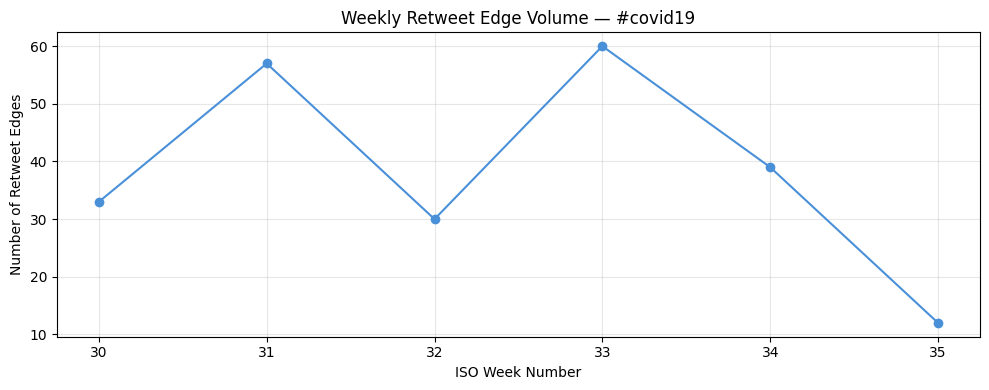

Temporal chart saved.


In [33]:
print("\n Temporal edge growth analysis")

rt_df["week"] = rt_df["date"].dt.isocalendar().week
weekly_edges  = rt_df.groupby("week").size().reset_index(name="edge_count")
print(weekly_edges)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(weekly_edges["week"], weekly_edges["edge_count"], marker="o", color="#4A90D9")
ax.set_title("Weekly Retweet Edge Volume — #covid19")
ax.set_xlabel("ISO Week Number")
ax.set_ylabel("Number of Retweet Edges")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "temporal_edge_growth.png", dpi=150)
plt.show()
print("Temporal chart saved.")

# Visualizations


 visualizations


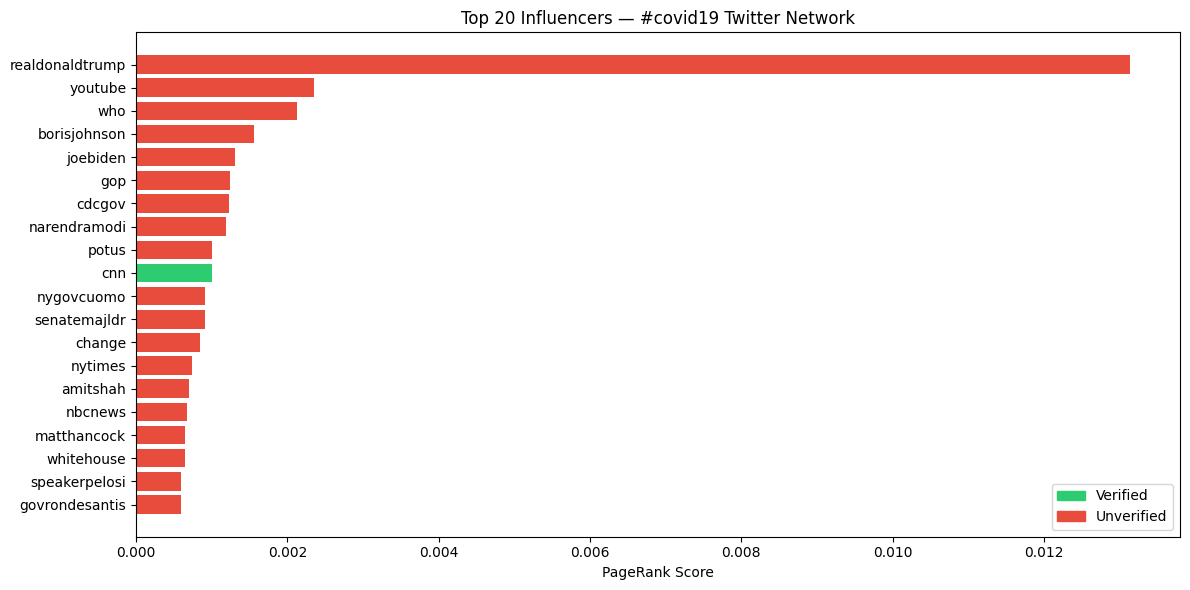

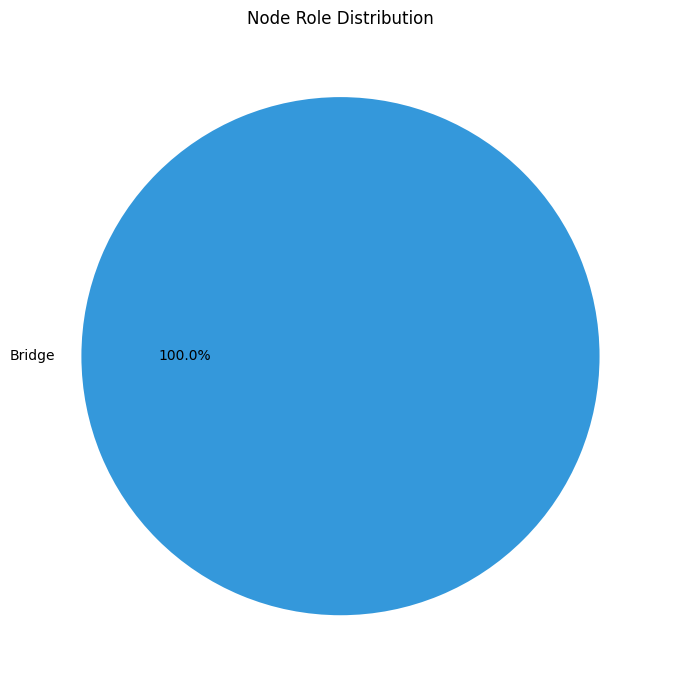

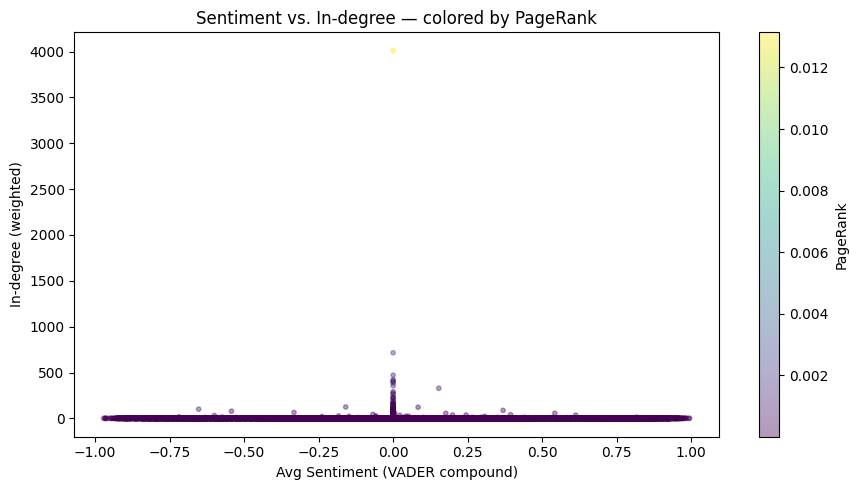

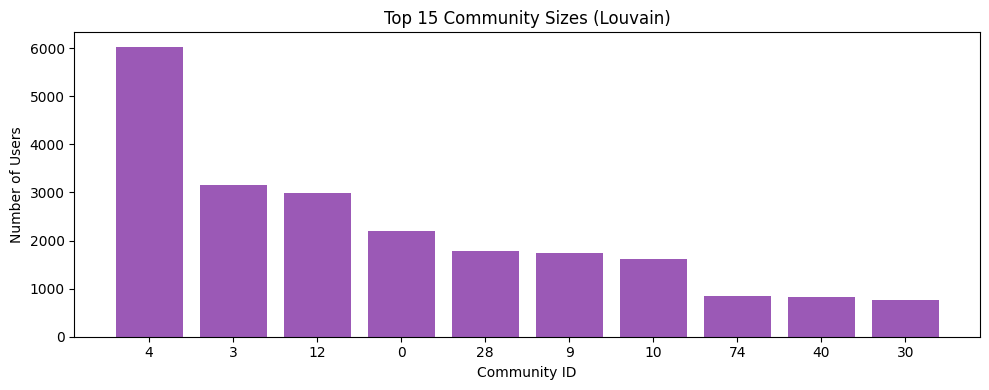

All charts saved.


In [34]:
print("\n visualizations")

## 15a — Top 20 users by PageRank (bar chart)
top20 = node_df.head(20)
fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#2ecc71" if v else "#e74c3c" for v in top20["verified"]]
bars = ax.barh(top20["user"][::-1], top20["pagerank"][::-1], color=colors[::-1])
ax.set_xlabel("PageRank Score")
ax.set_title("Top 20 Influencers — #covid19 Twitter Network")
from matplotlib.patches import Patch
legend = [Patch(color="#2ecc71", label="Verified"), Patch(color="#e74c3c", label="Unverified")]
ax.legend(handles=legend)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "top20_pagerank.png", dpi=150)
plt.show()

## 15b — Role distribution pie chart
role_counts = node_df["role"].value_counts()
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(role_counts, labels=role_counts.index, autopct="%1.1f%%",
       colors=["#3498db","#e74c3c","#2ecc71","#f39c12","#9b59b6"])
ax.set_title("Node Role Distribution")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "role_distribution.png", dpi=150)
plt.show()

## 15c — Sentiment vs in-degree scatter
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    node_df["avg_sentiment"], node_df["in_degree"],
    c=node_df["pagerank"], cmap="viridis",
    alpha=0.4, s=10
)
plt.colorbar(sc, ax=ax, label="PageRank")
ax.set_xlabel("Avg Sentiment (VADER compound)")
ax.set_ylabel("In-degree (weighted)")
ax.set_title("Sentiment vs. In-degree — colored by PageRank")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "sentiment_vs_indegree.png", dpi=150)
plt.show()

## 15d — Community size bar chart (top 15)
fig, ax = plt.subplots(figsize=(10, 4))
comm_df = pd.DataFrame(top_comms, columns=["community", "size"])
ax.bar(comm_df["community"].astype(str), comm_df["size"], color="#9b59b6")
ax.set_xlabel("Community ID")
ax.set_ylabel("Number of Users")
ax.set_title("Top 15 Community Sizes (Louvain)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "community_sizes.png", dpi=150)
plt.show()

print("All charts saved.")

# Interactive Pyvis Network

In [37]:
print("\n Building interactive Pyvis network …")

# Subset: top 300 nodes by PageRank
top_nodes = node_df.head(300)["user"].tolist()
G_sub     = G.subgraph(top_nodes).copy()

# Pre-build lookup dicts for speed
sentiment_lookup = dict(zip(node_df["user"], node_df["avg_sentiment"]))
role_lookup      = dict(zip(node_df["user"], node_df["role"]))

palette = ["#e74c3c","#3498db","#2ecc71","#f39c12","#9b59b6",
           "#1abc9c","#e67e22","#34495e","#e91e63","#00bcd4"]

net = Network(height="750px", width="100%", bgcolor="#1a1a2e",
              font_color="white", directed=True)
net.barnes_hut(gravity=-8000, central_gravity=0.3,
               spring_length=100, spring_strength=0.04)

for uid, data in G_sub.nodes(data=True):
    comm      = data.get("community", 0) % len(palette)
    size      = 5 + min(data.get("pagerank", 0) * 5000, 40)
    sentiment = sentiment_lookup.get(uid, 0)
    role      = role_lookup.get(uid, "N/A")

    # Sentiment formatted safely outside the f-string
    sent_str  = f"{sentiment:.2f}"

    title = (
        f"<b>{uid}</b><br>"
        f"Role: {role}<br>"
        f"PageRank: {data.get('pagerank', 0):.5f}<br>"
        f"In-degree: {data.get('in_degree', 0)}<br>"
        f"Community: {data.get('community', '?')}<br>"
        f"Verified: {data.get('verified', False)}<br>"
        f"Sentiment: {sent_str}"
    )
    net.add_node(uid, label=uid, color=palette[comm], size=size, title=title)

for u, v, data in G_sub.edges(data=True):
    net.add_edge(u, v, value=data.get("weight", 1), color="#ffffff22")

net.save_graph(OUTPUT_DIR + "network_interactive.html")
print(f"Interactive network saved → {OUTPUT_DIR}network_interactive.html")



 Building interactive Pyvis network …
Interactive network saved → /content/sna_outputs/network_interactive.html


#Echo Chamber Analysis

In [38]:
print("\n Echo Chamber Analysis")

intra, inter = 0, 0
for u, v in G.edges():
    cu = partition.get(u, -1)
    cv = partition.get(v, -1)
    if cu == cv:
        intra += 1
    else:
        inter += 1

total = intra + inter
print(f"  Intra-community edges : {intra:,}  ({intra/total*100:.1f}%)")
print(f"  Inter-community edges : {inter:,}  ({inter/total*100:.1f}%)")
if intra / total > 0.70:
    print("Strong echo chamber signal — >70% of edges are within communities")
else:
    print(" Network shows cross-community information flow")


 Echo Chamber Analysis
  Intra-community edges : 67,855  (92.0%)
  Inter-community edges : 5,936  (8.0%)
Strong echo chamber signal — >70% of edges are within communities


# Community Profile Report

In [39]:
print("\n Community Profiles (top 5 communities)")

# Map users back to original df
df["user_lower"] = df["user_name"].str.lower().str.strip()
df["community"]  = df["user_lower"].map(partition)

# Attach sentiment to df (already computed)
comm_report = []
for cid, size in comm_sizes.most_common(5):
    sub = df[df["community"] == cid]
    top_tags  = Counter([t for tags in sub["text"].apply(extract_hashtags) for t in tags]).most_common(5)
    avg_sent  = sub["sentiment"].mean() if "sentiment" in sub.columns else 0
    pct_verif = sub["user_verified"].mean() * 100 if "user_verified" in sub.columns else 0
    print(f"\n  Community {cid} ({size:,} users)")
    print(f"    Avg sentiment  : {avg_sent:.3f}")
    print(f"    % Verified     : {pct_verif:.1f}%")
    print(f"    Top hashtags   : {[t[0] for t in top_tags]}")


 Community Profiles (top 5 communities)

  Community 4 (6,028 users)
    Avg sentiment  : -0.091
    % Verified     : 2.6%
    Top hashtags   : ['coronavirus', 'trump', 'trumpvirus', 'pandemic', 'covid2019']

  Community 3 (3,150 users)
    Avg sentiment  : 0.088
    % Verified     : 48.1%
    Top hashtags   : ['coronavirus', 'indiafightscorona', 'coronavirusupdates', 'india', 'bignews']

  Community 12 (2,988 users)
    Avg sentiment  : -0.015
    % Verified     : 6.5%
    Top hashtags   : ['coronavirus', 'uk', 'brexit', 'borisjohnson', 'torycorruption']

  Community 0 (2,204 users)
    Avg sentiment  : -0.010
    % Verified     : 9.5%
    Top hashtags   : ['coronavirus', 'trump', 'coronavirusoutbreak', 'coronavirusupdates', 'pandemic']

  Community 28 (1,776 users)
    Avg sentiment  : 0.002
    % Verified     : 11.0%
    Top hashtags   : ['auspol', 'coronavirus', 'agedcare', 'thedrum', 'australia']


# Export Final Summary

In [40]:
summary = {
    "total_nodes"         : G.number_of_nodes(),
    "total_edges"         : G.number_of_edges(),
    "density"             : nx.density(G),
    "num_communities"     : num_communities,
    "modularity"          : modularity,
    "avg_clustering"      : avg_clust,
    "intra_edge_pct"      : round(intra / total * 100, 2),
    "inter_edge_pct"      : round(inter / total * 100, 2),
    "top_influencer"      : node_df.iloc[0]["user"],
    "top_influencer_pr"   : node_df.iloc[0]["pagerank"],
}

pd.DataFrame([summary]).to_csv(OUTPUT_DIR + "network_summary.csv", index=False)
print("PIPELINE COMPLETE")

PIPELINE COMPLETE
